<a href="https://colab.research.google.com/github/qjpbtuzara-ai/CPE311-CPE22S3/blob/main/Tuzara_Quiz2_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

#Extract
csv_file = "RT_IOT2022.csv"
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)
print(df.head())
print(df.shape)


Using Colab cache for faster access to the 'rt-iot2022real-time-internet-of-things' dataset.
Path to dataset files: /kaggle/input/rt-iot2022real-time-internet-of-things
   no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0   0      38667       1883   tcp    mqtt      32.011598             9   
1   1      51143       1883   tcp    mqtt      31.883584             9   
2   2      44761       1883   tcp    mqtt      32.124053             9   
3   3      60893       1883   tcp    mqtt      31.961063             9   
4   4      51087       1883   tcp    mqtt      31.902362             9   

   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...  active.std  \
0             5                  3                  3  ...         0.0   
1             5                  3                  3  ...         0.0   
2             5                  3                  3  ...         0.0   
3             5                  3                  3  ...         0.0   
4             5 

In [28]:
#Tranform
print(df.isnull().sum().sum())

df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['label_encoded'] = df['Attack_type'].astype('category').cat.codes

df_numeric = df.select_dtypes(include=['float64', 'int64'])

print(df.shape)


0
(123117, 86)


/tmp/ipykernel_771/615938537.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


                  no      id.orig_p      id.resp_p  flow_duration  \
count  123117.000000  123117.000000  123117.000000  123117.000000   
mean    37035.089248   34639.258738    1014.305092       3.809566   
std     30459.106367   19070.620354    5256.371994     130.005408   
min         0.000000       0.000000       0.000000       0.000000   
25%      6059.000000   17702.000000      21.000000       0.000001   
50%     33100.000000   37221.000000      21.000000       0.000004   
75%     63879.000000   50971.000000      21.000000       0.000005   
max     94658.000000   65535.000000   65389.000000   21728.335578   

        fwd_pkts_tot   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  \
count  123117.000000  123117.000000      123117.000000      123117.000000   
mean        2.268826       1.909509           1.471218           0.820260   
std        22.336565      33.018311          19.635196          32.293948   
min         0.000000       0.000000           0.000000           0.000

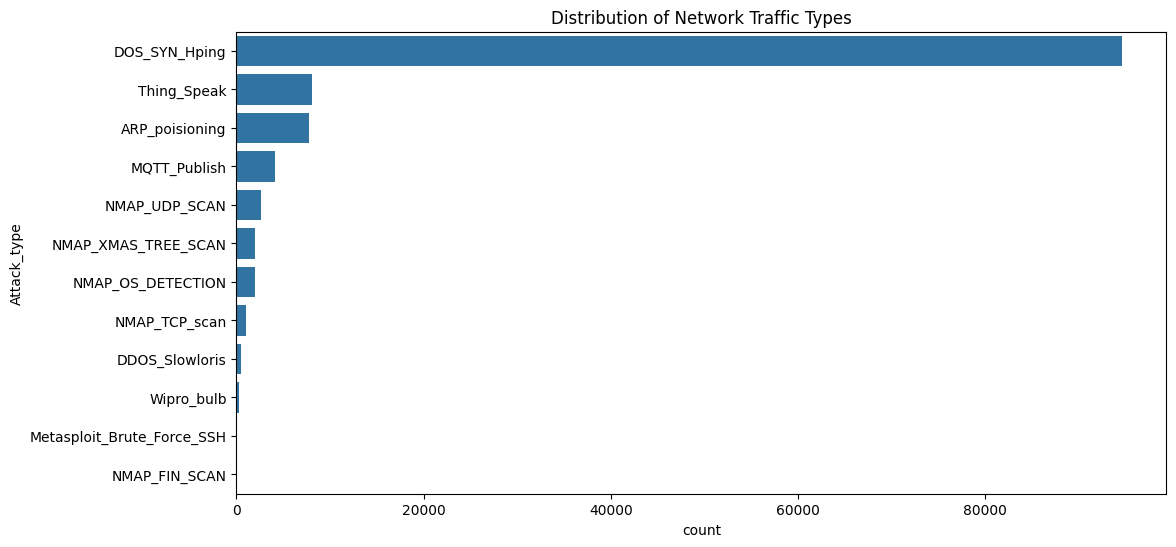

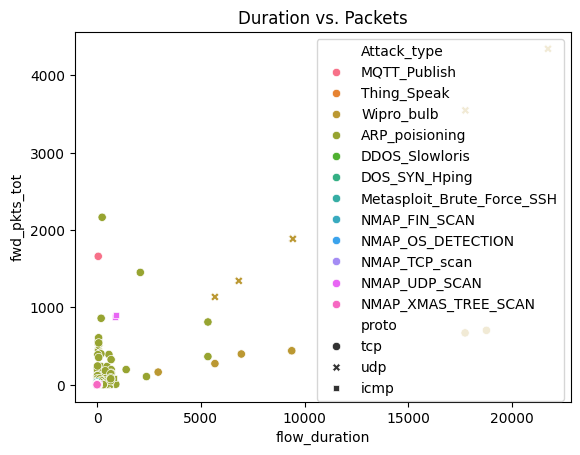

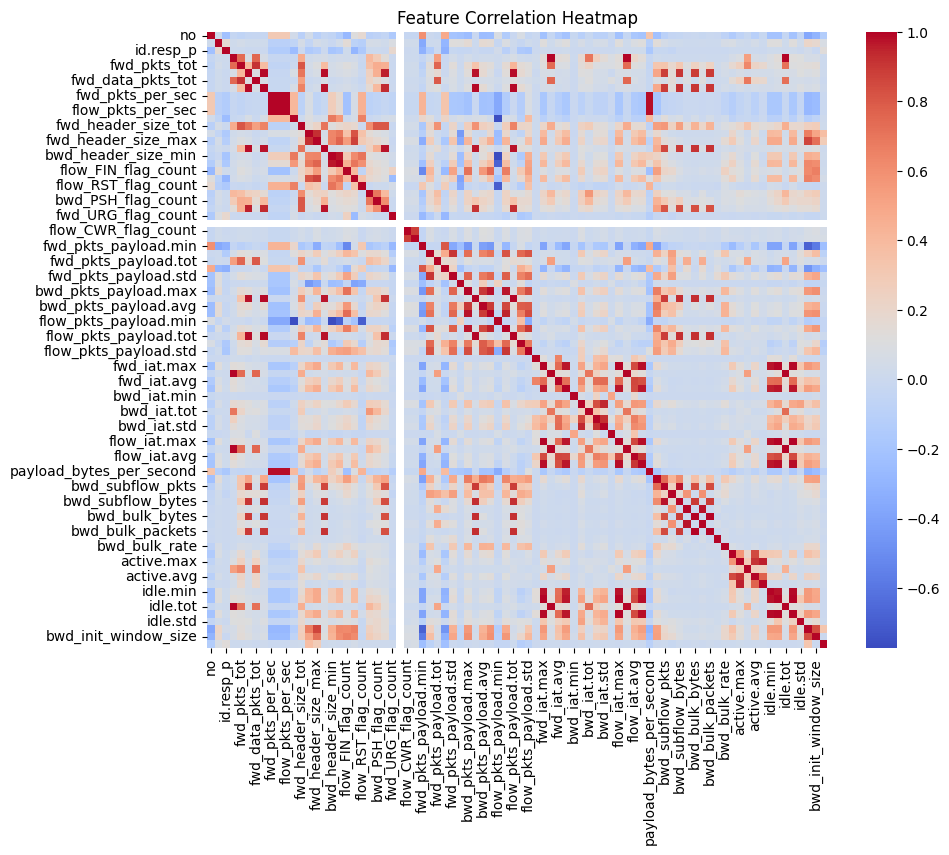

In [30]:
#Load
import matplotlib.pyplot as plt
import seaborn as sns

stats = df.describe()
print(stats)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Attack_type', order=df['Attack_type'].value_counts().index)
plt.title('Distribution of Network Traffic Types')
plt.show()

sns.scatterplot(x='flow_duration', y='fwd_pkts_tot', data=df, hue='Attack_type', style='proto')
plt.title('Duration vs. Packets')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
